In [1]:
# !pip install -U ultralytics

In [2]:
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")
import torch
print(f"Torch version: {torch.__version__}")
import cv2
import numpy as np
from ultralytics import YOLO
import os
from PIL import Image
from torchvision import transforms
from IPython.display import display, clear_output 
from collections import defaultdict

import cv2
import numpy as np
from collections import defaultdict
from PIL import Image
from IPython.display import display, clear_output

Ultralytics version: 8.4.32
Torch version: 2.5.1+cu124


In [3]:

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

device = "cuda" if torch.cuda.is_available() else "cpu"
x = torch.rand(10000,10000).to(device)
print(x.device)

2.5.1+cu124
12.4
True
NVIDIA GeForce RTX 2060 SUPER
cuda:0


In [4]:
!nvidia-smi

Tue Mar 31 00:01:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.74                 Driver Version: 591.74         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   53C    P0             48W /  175W |    2098MiB /   8192MiB |     12%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

data\traffic.mp4
Detection_dev\model_training\yolo8_v0\main (1).ipynb

In [5]:
model = YOLO('yolov8n.pt')
video_path = r"data\traffic.mp4"
cap = cv2.VideoCapture(video_path)

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [7]:
MAX_UPDATES = 100

class Car:
    def __init__(self, trackId: int):
        self.trackId = trackId
        self.x = 0.0
        self.y = 0.0
        self.w = 0.0
        self.h = 0.0
        self.maxConfidence = 0.0
        self.label = ""
        self.history = []
        self.lastCrop = None
        self.updateCount = 0

    def __del__(self):
        pass

    def checkType(self):
        # Placeholder classification logic
        return "sedan"

    def update(self, box: tuple, confidence: float, label: str, frame: np.ndarray) -> None:
        self.updateCount += 1
        self.x, self.y, self.w, self.h = box
        self.label = label
        self.history.append((float(self.x), float(self.y + self.h / 2)))
        
        if confidence > self.maxConfidence:
            self.maxConfidence = confidence
            
            x1 = int(self.x - self.w / 2)
            y1 = int(self.y - self.h / 2)
            x2 = int(self.x + self.w / 2)
            y2 = int(self.y + self.h / 2)
            
            crop = frame[max(0, y1):min(frame.shape[0], y2), max(0, x1):min(frame.shape[1], x2)]
            if crop.size > 0:
                self.lastCrop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
                self.checkType()

        if self.updateCount >= MAX_UPDATES or self.maxConfidence < 0.5:
            self.__del__()
            pass

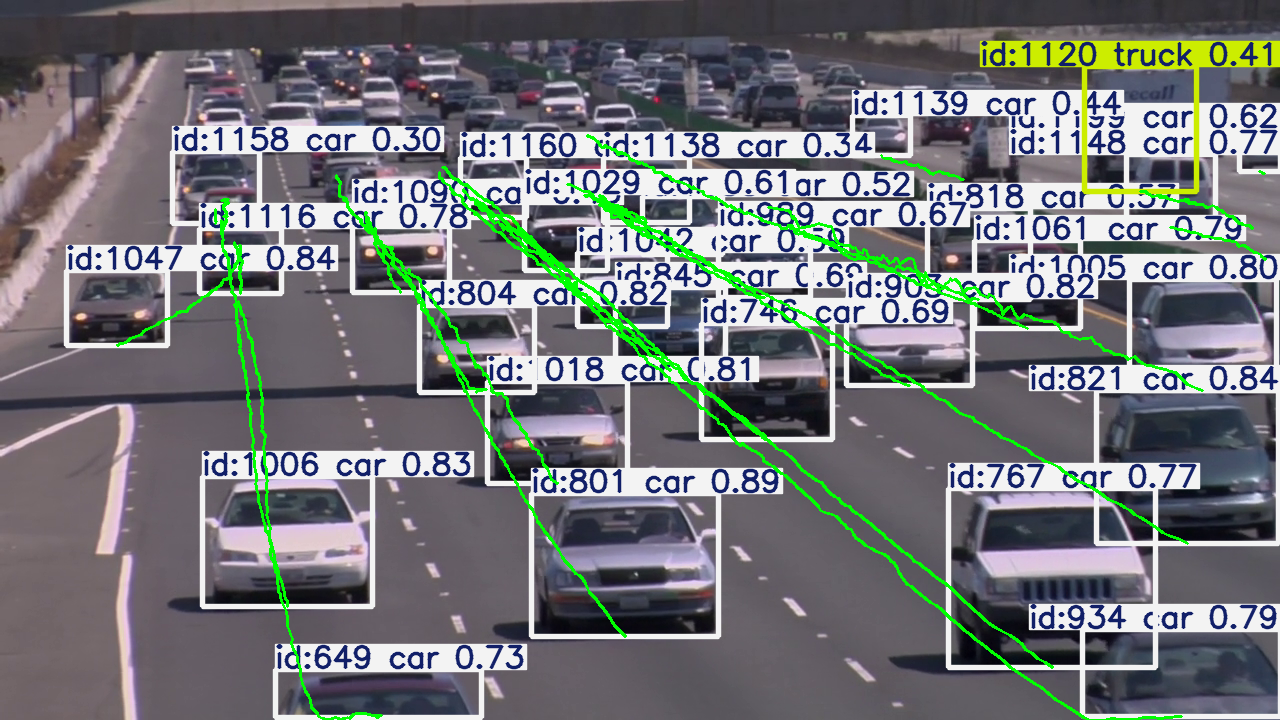

In [ ]:
import cv2
import numpy as np
from collections import defaultdict
from PIL import Image
from IPython.display import display, clear_output

CONF_THRESHOLD = 0.01
OUTPUT_PATH = 'trajectory.mp4'
VIDEO_FOURCC = 'mp4v'
TRACK_COLOR = (0, 255, 0)
LINE_THICKNESS = 2


frameWidth = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frameHeight = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*VIDEO_FOURCC)
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (frameWidth, frameHeight))

carsDict = {}

try:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        results = model.track(
            source=frame, 
            conf=CONF_THRESHOLD, 
            persist=True,  
            verbose=False, 
            device=0 if device == 'cuda' else 'cpu'
        )

        annotatedFrame = results[0].plot()

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xywh.cpu()
            trackIds = results[0].boxes.id.int().cpu().tolist()
            classIndices = results[0].boxes.cls.int().cpu().tolist()
            confidences = results[0].boxes.conf.cpu().tolist()

            for box, trackId, classIdx, conf in zip(boxes, trackIds, classIndices, confidences):
                if trackId not in carsDict:
                    carsDict[trackId] = Car(trackId)
                
                car = carsDict[trackId]
                car.update(box, conf, model.names[classIdx], frame)
                
                points = np.array(car.history).astype(np.int32).reshape((-1, 1, 2))
                cv2.polylines(annotatedFrame, [points], isClosed=False, color=TRACK_COLOR, thickness=LINE_THICKNESS)

        out.write(annotatedFrame)
        annotatedFrameRgb = cv2.cvtColor(annotatedFrame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(annotatedFrameRgb)

        clear_output(wait=True)
        display(img)

except KeyboardInterrupt:
    pass

finally:
    cap.release()
    out.release()
    cv2.destroyAllWindows()

for carId, carObj in carsDict.items():
    if carObj.lastCrop is not None:
        print(f"Car ID: {carId} | Label: {carObj.label} | Conf: {carObj.confidence:.2f}")
        display(Image.fromarray(carObj.lastCrop))

In [ ]:
for carId, carObj in carsDict.items():
    if carObj.lastCrop is not None:
        print(f"ID: {carId} | Label: {carObj.label} | Max Conf: {carObj.maxConfidence:.2f}")
        display(Image.fromarray(carObj.lastCrop))